# Amazon Sales Data Analysis using Python and SQL

## Project Overview:
This project focuses on analyzing Amazon sales data using Python and SQL. The main objective is to extract meaningful business insights from raw data such as sales trends, customer behavior, product performance, and revenue distribution.

## Objective:

*   To analyze overall sales performance

*   To identify top and least selling products

*   To understand revenue trends over time
*   To analyze customer purchasing behavior


*   To evaluate payment methods and order status


*   To study city-wise sales performance

## Tools & Technologies Used:

*   Python

*   Pandas

*   Matplotlib
*   SQLite (SQL)


*   Google Colab


## Dataset Description:
The dataset contains Amazon sales records with the following features:

*   Product Name

*   Category

*   Quantity Sold



*   Total Sales / Revenue
*   Customer Name


*   Customer Location (City)


*   Payment Method


*   Order Date


*   Order Status

## Data Cleaning:

*   Removed extra spaces from column names

*   Converted column names into lowercase format
*   Handled and standardized date format


*   Ensured data consistency for analysis

## Data Analysis Performed:

*   Calculation of total revenue

*   Total number of orders

*   Total quantity sold

*   Average order value

*   Top 5 selling products

*   Least selling products
*   Monthly sales analysis


*   Category-wise revenue analysis


*   Customer-wise spending analysis


*   Payment method distribution


*   Order status analysis


*   City-wise revenue analysis

## Data Visualization:

*   Line chart for monthly revenue trend

*   Bar chart for top selling products

*   Bar chart for category revenue
*   Pie chart for payment methods


*   Bar chart for order status distribution















In [53]:
#========================
# IMPORT LIBRARIES
#========================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt



**Insight:**
"The project uses SQLite for database operations, Pandas for data analysis, Matplotlib for chart creation, and Seaborn for advanced visualizations. These libraries together help in performing complete data analysis and generating business insights."

In [54]:
#=====================
# UPLOAD DATASET
#=====================

from google.colab import files
uploaded = files.upload()

Saving amazon_sales_data.csv to amazon_sales_data (3).csv


**Insight:**
"This step is used to upload the dataset file from the local system into Google Colab so that it can be used for data analysis and SQL operations."

In [55]:
#=======================
# LOAD DATASET
#=======================

df = pd.read_csv("amazon_sales_data.csv")

print(df.head())

  Order ID      Date        Product     Category  Price  Quantity  \
0  ORD0001  14-03-25  Running Shoes     Footwear     60         3   
1  ORD0002  20-03-25     Headphones  Electronics    100         4   
2  ORD0003  15-02-25  Running Shoes     Footwear     60         2   
3  ORD0004  19-02-25  Running Shoes     Footwear     60         3   
4  ORD0005  10-03-25     Smartwatch  Electronics    150         3   

   Total Sales  Customer Name Customer Location Payment Method     Status  
0          180     Emma Clark          New York     Debit Card  Cancelled  
1          400  Emily Johnson     San Francisco     Debit Card    Pending  
2          120       John Doe            Denver     Amazon Pay  Cancelled  
3          180  Olivia Wilson            Dallas    Credit Card    Pending  
4          450     Emma Clark          New York     Debit Card    Pending  


**Insight:**
"The dataset is loaded using Pandas, and the first five rows are displayed to understand the structure, columns, and sample records of the data."

In [56]:
#========================
# CHECK COLUMN NAMES
#========================
print(df.columns.tolist())

['Order ID', 'Date', 'Product', 'Category', 'Price', 'Quantity', 'Total Sales', 'Customer Name', 'Customer Location', 'Payment Method', 'Status']


**Insight:**
"This step displays all column names present in the dataset, helping to understand the data structure and use correct column names during analysis."

In [57]:
#============================
# CLEAN COLUMN NAMES
#============================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+","_",regex=True)
)

print(df.columns.tolist())

['order_id', 'date', 'product', 'category', 'price', 'quantity', 'total_sales', 'customer_name', 'customer_location', 'payment_method', 'status']


**Insight:**
"This step cleans the column names by removing extra spaces, converting them to lowercase, and replacing spaces with underscores. It makes the dataset more organized and easier to use in SQL queries and Python analysis."

In [58]:
#========================
# CREATE SQL DATABASE
#========================

conn = sqlite3.connect("amazon.db")


**Insight:**
"This step creates a SQL database connection named amazon.db, which is used to store and manage the dataset for SQL analysis."

In [59]:
#========================
# STORE DATA IN SQL
#========================

df.to_sql("orders",conn,if_exists="replace",index=False)

250

**Insight:**
"This step stores the cleaned dataset into SQL database as a table named orders. It allows SQL queries to be performed easily on the data."

In [60]:
#=========================
# CHECK TABLES
#=========================

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
     conn
)

print(tables)

     name
0  orders


**Insight:**
"This step checks all tables available in the SQL database to confirm that the dataset has been successfully stored."

In [61]:
#==============================
# SHOW DATA FROM SQL TABLE
#==============================

data = pd.read_sql(
    "SELECT * FROM orders LIMIT 5",
     conn
)

print(data)

  order_id      date        product     category  price  quantity  \
0  ORD0001  14-03-25  Running Shoes     Footwear     60         3   
1  ORD0002  20-03-25     Headphones  Electronics    100         4   
2  ORD0003  15-02-25  Running Shoes     Footwear     60         2   
3  ORD0004  19-02-25  Running Shoes     Footwear     60         3   
4  ORD0005  10-03-25     Smartwatch  Electronics    150         3   

   total_sales  customer_name customer_location payment_method     status  
0          180     Emma Clark          New York     Debit Card  Cancelled  
1          400  Emily Johnson     San Francisco     Debit Card    Pending  
2          120       John Doe            Denver     Amazon Pay  Cancelled  
3          180  Olivia Wilson            Dallas    Credit Card    Pending  
4          450     Emma Clark          New York     Debit Card    Pending  


**Insight:**
"This step retrieves the first five records from the SQL table to verify that the data has been stored correctly in the database."

In [62]:
#=======================
# TOTAL REVENUE
#=======================

total_revenue = pd.read_sql("""
SELECT SUM(total_Sales) as revenue
FROM orders
""", conn)

print(total_revenue)

   revenue
0   243845


**Insight:**
"The total revenue generated is 243,845, which represents the overall earnings from all sales in the dataset. This indicates the total business performance in monetary terms."

In [63]:
#==========================
# TOTAL ORDERS
#==========================

total_orders = pd.read_sql("""

SELECT COUNT(*) AS total_orders
FROM orders

""", conn)

print(total_orders)

   total_orders
0           250


**Insight:**
"The total number of orders is 250, which shows how many individual transactions were made in the dataset. This helps understand customer activity and overall order volume."

In [64]:
#======================
# TOTAL QUANTITY SOLD
#======================
total_qua = pd.read_sql("""
SELECT SUM(quantity) AS total_quantity
FROM orders
""", conn)

print(total_qua)

   total_quantity
0             714


**Insight:**
"The total quantity sold is 714, which represents the overall number of product units sold across all orders in the dataset. This helps understand the total sales volume of the business."

In [65]:
#======================
# AVERAGE ORDER VALUE
#======================

avg_order = pd.read_sql("""
SELECT AVG(total_sales) as avg_order_value
FROM orders
""", conn)

print(avg_order)

   avg_order_value
0           975.38


**Insight:**
"The Average order value is 975.38, which means on average each customer spends around 975 per order. This helps in understanding customer spending behavior."

In [66]:
#=========================
# TOP CUSTOMERS BY SALES
#=========================

top_customers = pd.read_sql("""

SELECT customer_name,
SUM(total_sales) as spent
FROM orders
GROUP BY customer_name
ORDER BY spent DESC
LIMIT 5

""", conn)

print(top_customers)

   customer_name  spent
0  Olivia Wilson  36170
1     Jane Smith  31185
2     Emma Clark  29700
3       John Doe  26870
4  Emily Johnson  23475


**Insight:**
"The top customers are Olivia Wilson (36,170), followed by Jane Smith (31,185) and Emma Clark (29,700). These customers contribute significantly to total revenue, showing they are high-value and loyal buyers. Focusing on such customers can help improve retention and sales."

In [67]:
#========================
# TOP 5 SELLING PRODUCTS
#========================

top_products = pd.read_sql("""

SELECT product,
 SUM(quantity) as total_sold
FROM orders
GROUP BY product
ORDER BY total_sold DESC
LIMIT 5
""", conn)

print(top_products)

         product  total_sold
0     Smartwatch         105
1     Smartphone          97
2         Laptop          73
3     Headphones          73
4  Running Shoes          72


**Insight:**
"The top-selling products are Smartwatch (105 units), followed by Smartphones (97). Laptop and Headphones both sold 73 units, while Running Shoes sold 72 units. This shows that electronic and wearable devices are the most in-demand products."

In [68]:
#===========================
# LEAST SELLING PRODUCTS
#===========================

least_products = pd.read_sql("""

SELECT product,
 SUM(quantity) as total_sold
FROM orders
GROUP BY product
ORDER BY total_sold ASC
LIMIT 5
""", conn)

print(least_products)

           product  total_sold
0  Washing Machine          45
1          T-Shirt          53
2            Jeans          62
3     Refrigerator          65
4             Book          69


"The least-selling products are Washing Machine (45 units), followed by T-shirt (53) and Jeans (62). Refrigerator (65) and Book (69) also have lower sales compared to other products. This indicates that these items have comparatively lower demand and may need better marketing or promotions."

In [69]:
#=============================
# CATEGORY-WISE SALES ANALYSIS
#=============================

category_analysis = pd.read_sql("""

SELECT category,
SUM(total_sales) AS revenue
FROM orders
GROUP BY category
ORDER BY revenue DESC
""", conn)

print(category_analysis)

          category  revenue
0      Electronics   129950
1  Home Appliances   105000
2         Footwear     4320
3         Clothing     3540
4            Books     1035


**Insight:**
"The highest revenue is generated by Electronics, followed by Home Appliances. Footwear, Clothing, and Books contribute much lower revenue. This shows that electronics dominate overall business revenue."

In [70]:
#=============================
# MONTHLY SALES ANALYSIS
#=============================

monthly_sales = pd.read_sql("""

SELECT substr(date,4,2) AS month,
SUM(total_sales) AS revenue
FROM orders
GROUP BY month
ORDER BY month
""", conn)

print(monthly_sales)

  month  revenue
0    02   122695
1    03   117730
2    04     3420


**Insight:**
"The highest revenue is generated in Month 2, followed closely by Month 3. However, Month 4 shows a sharp decline, indicating a significant drop in sales which may required investigation such as demand reduction, seasonal effect, or data inconsistency."

In [71]:
#===============================
# PAYMENT METHOD ANALYSIS
#===============================

payment_analysis = pd.read_sql("""

SELECT payment_method,
 COUNT(*) AS orders
FROM orders
GROUP BY payment_method
ORDER BY orders DESC
""", conn)

print(payment_analysis)

  payment_method  orders
0         PayPal      60
1    Credit Card      54
2     Debit Card      53
3      Gift Card      42
4     Amazon Pay      41


**Insight:**
"PayPal is the most preferred payment method with 60 orders, followed by Credit Card (54) and Debit Card (53). Gift Cards (42) and Amazon Pay (41) are used less frequently. This shows that customers mainly prefer digital wallets and card-based payments for convenience and trust."

In [72]:
#==============================
# ORDER STATUS ANALYSIS
#==============================

status_analysis = pd.read_sql("""

SELECT status,
 COUNT(*) AS total
FROM orders
GROUP BY status
""", conn)

print(status_analysis)

      status  total
0  Cancelled     77
1  Completed     88
2    Pending     85


**Insight:**
"Most orders are Completed, showing good successful transaction rate. Pending orders are almost equal, indicating many orders are still in processing. Cancelled orders are slightly lower but still significant, suggesting there is room to improve order confirmation and customer experience."

In [73]:
#=========================
# CITY-WISE SALES ANALYSIS
#=========================

city_wise = pd.read_sql("""
SELECT customer_location, SUM(total_sales) as revenue
FROM orders
GROUP BY customer_location
ORDER BY revenue DESC
""", conn )

print(city_wise)

  customer_location  revenue
0             Miami    31700
1            Denver    29785
2           Houston    28390
3            Dallas    27145
4           Seattle    26890
5            Boston    26170
6           Chicago    20810
7          New York    18940
8       Los Angeles    17820
9     San Francisco    16195


**Insight:**
"Miami generates the highest revenue, followed by Denver and Houston. Cities like Dallas, Seattle, and Boston show moderate performance, while Chicago, New York, Los Angeles, and San Francisco have comparatively lower revenue. This indicates strong regional variation in sales performance, with Miami being the top-performing market."

# Data Visualization using Python

<Figure size 1000x500 with 0 Axes>

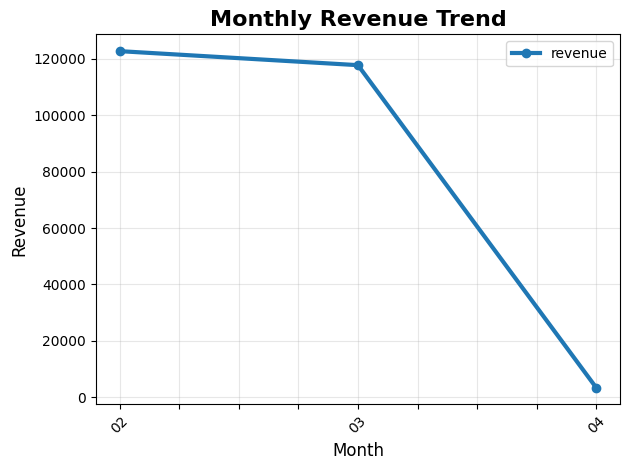

In [74]:
#===============================
# MONTHLY REVENUE GRAPH
#===============================

plt.figure(figsize=(10,5))

monthly_sales.plot(
    x="month",
    y="revenue",
    kind="line",
    marker="o",
    linewidth=3
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


<Figure size 1000x500 with 0 Axes>

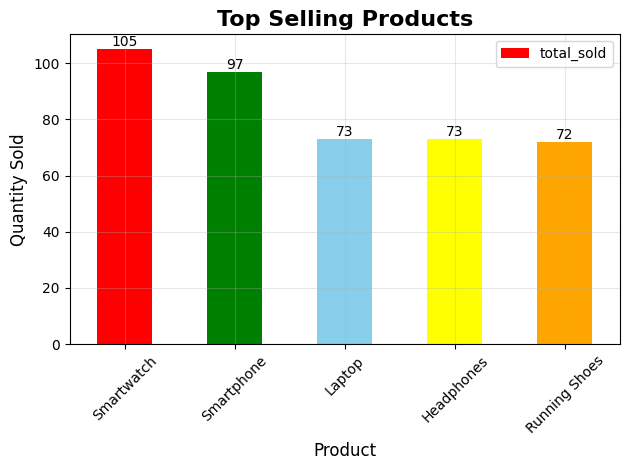

In [75]:
#========================
# TOP PRODUCTS GRAPH
#========================

plt.figure(figsize=(10,5))

ax = top_products.plot(
    x="product",
    y="total_sold",
    kind="bar",
    color=["red","green","skyblue","yellow","orange"]
)

plt.title("Top Selling Products", fontsize=16, fontweight="bold")
plt.xlabel("Product", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

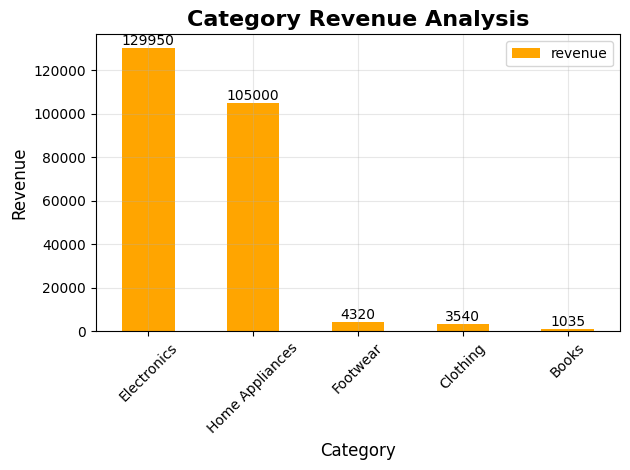

In [76]:
#=========================
# CATEGORY REVENUE GRAPH
#=========================
plt.figure(figsize=(10,5))

ax = category_analysis.plot(
    x="category",
    y="revenue",
    kind="bar",
    color="orange"
)

plt.title("Category Revenue Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

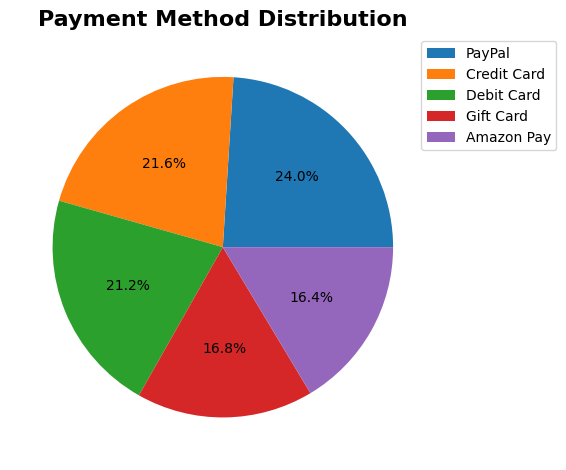

In [77]:
#=============================
# PAYMENT METHOD PIE CHART
#==============================

payment_analysis.plot(
    x="payment_method",
    y="orders",
    kind="pie",
    autopct="%1.1f%%",
    labels=None
)

plt.title("Payment Method Distribution", fontsize=16, fontweight="bold")
plt.ylabel("")

plt.legend(
    payment_analysis["payment_method"],
    bbox_to_anchor=(1.3,1),
    loc="upper right",

)

plt.tight_layout()

plt.show()

<Figure size 1000x500 with 0 Axes>

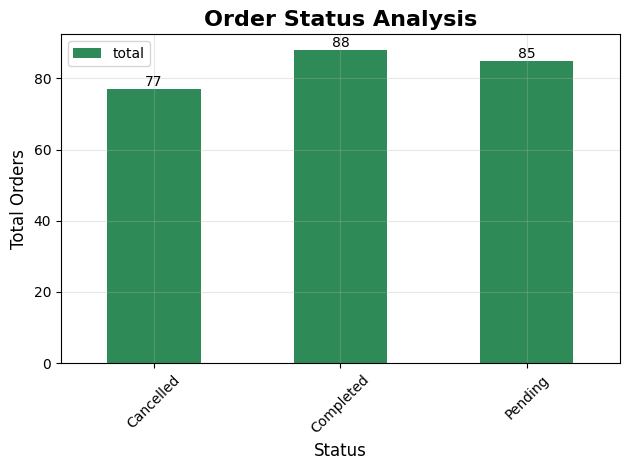

In [78]:
#=====================
# ORDER STATUS CHART
#=====================

plt.figure(figsize=(10,5))

ax = status_analysis.plot(
    x="status",
    y="total",
    kind="bar",
    color="seagreen"
)

plt.title("Order Status Analysis", fontsize=16, fontweight="bold")
plt.xlabel("Status", fontsize=12)
plt.ylabel("Total Orders", fontsize=12)

for i in ax.containers:
    ax.bar_label(i)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Conclusion:
This analysis helps in understanding overall business performance and customer behavior. It highlights strong and weak areas in sales, which can help in making data-driven business decisions.